# RWA oscillators do not follow a Boltzmann distribution????

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import diffrax
import matplotlib.pyplot as plt
from functools import partial

from diffrax import ControlTerm, MultiTerm, ODETerm, PIDController

jax.config.update("jax_enable_x64", True)

## Setup Problem

In [2]:
# ----------------------------
# 1. Define Parameters
# ----------------------------


# Physical Constants and Parameters
M1 = 1.0
M2 = 1.0

w1 = 1.0          # Natural frequency of oscillator 1 (rad/s)
w2 = 1.0          # Natural frequency of oscillator 2 (rad/s)

wp1 = 2*(w1+0.0)  # Driving frequency for oscillator 1 (rad/s)
wp2 = 2*(w2+0.0)  # Driving frequency for oscillator 2 (rad/s)

period1 = 2*jnp.pi/w1
period2 = 2*jnp.pi/w2

Fp1 = 0.0        # Amplitude of the wp driving for oscillator 1
Fp2 = 0.00         # Amplitude of the wp driving for oscillator 2

Q1 = 1000.0       # Quality factor for oscillator 1
Q2 = 1000.0       # Quality factor for oscillator 2

GAMMA1 = w1/(2*Q1)
GAMMA2 = w2/(2*Q2)

gamma1 = 0.00    # Nonlinearity coefficient for oscillator 1 (Duffing term)
gamma2 = 0.00    # Nonlinearity coefficient for oscillator 2 (Duffing term)

c = .01


k_B = 1.0             # Boltzmann's constant (arbitrary units for simulation)
T = 1.0             # Temperature (K)
    # Noise strength

# Simulation Parameters
t0 = 0.0  
num_periods = 10000000# Start time
period = 2*jnp.pi/w1
t1 = num_periods*period
dt0 = period/1000
num_pts_per_period = 100
ts_dim = jnp.linspace(t0, t1, 10000)
saveat = diffrax.SaveAt(ts=ts_dim)

y0_QP = jnp.array([0, 0, 0, 0])


CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [3]:
def Hamiltonian(Q1, P1, Q2, P2, args):
    dw = wp1/2 - w1  # detuning term
    
    # Parameters of the Hidden oscillator
    gamma_h, wp_h, Fp_h = args
    
    # Single oscillator terms (for both oscillators)
    H1 = 3*gamma1/(16*wp1) * (Q1**2 + P1**2)**2 + dw/2 *(Q1**2 - P1**2) + Fp1/(4*M1*wp1) * (P1**2 - Q1**2)
    H2 = 3*gamma_h/(16*wp_h) * (Q2**2 + P2**2)**2 + dw/2 *(Q2**2 - P2**2) + Fp_h/(4*M2*wp_h) * (P2**2 - Q2**2)

    # Coupling term
    H_coupling = c/4 * ((Q1 - Q2)**2 + (P1 - P2)**2)
    
    return H1 + H2 + H_coupling


def drift_QP_fn(t, state, args):
    """
    Drift function for the RWA equations
    """
    Q1, P1, Q2, P2 = state  # Unpack all state variables
    
    # Calculate gradients of Hamiltonian for both oscillators
    dQ1dt =  jax.grad(Hamiltonian, 1)(Q1, P1, Q2, P2, args) - GAMMA1*Q1
    dP1dt = -jax.grad(Hamiltonian, 0)(Q1, P1, Q2, P2, args) - GAMMA1*P1
    dQ2dt =  jax.grad(Hamiltonian, 3)(Q1, P1, Q2, P2, args) - GAMMA2*Q2
    dP2dt = -jax.grad(Hamiltonian, 2)(Q1, P1, Q2, P2, args) - GAMMA2*P2
    
    return jnp.array([dQ1dt, dP1dt, dQ2dt, dP2dt])



def diffusion_QP_fn(t, state, args):
    """
    Diffusion matrix for Q and P equations for two coupled oscillators.
    Returns a 4x4 matrix with noise terms for both oscillators.
    """
    # Noise strength for oscillator 1
    noise_strength_QP1 = jnp.sqrt(2*GAMMA1*k_B * T/(M1*w1**2))
    # Noise strength for oscillator 2  
    noise_strength_QP2 = jnp.sqrt(2*GAMMA2*k_B * T/(M2*w2**2))
    
    # Create 4x4 matrix for both oscillators [Q1, P1, Q2, P2]
    noise_matrix = jnp.zeros((4, 4))
    noise_matrix = noise_matrix.at[0:2, 0:2].set(noise_strength_QP1 * jnp.eye(2))  # First oscillator
    noise_matrix = noise_matrix.at[2:4, 2:4].set(noise_strength_QP2 * jnp.eye(2))  # Second oscillator
    return noise_matrix



In [4]:
@jax.jit
def solve_SDE_QP(args, seed=0):
    """
    Solve the SDE for the QP equations with configurable random seed
    
    Args:
        args: Parameters for the SDE
        seed (int): Random seed for noise generation (default=0)
    
    Returns:
        Array of solution samples
    """
    # Define state shape
    w_shape = (4,)  # state is (Q, P)
    
    # Create Brownian motion with specified seed
    brownian_motion_QP = diffrax.VirtualBrownianTree(
        t0, t1, 1.e-11, w_shape, jr.PRNGKey(seed), diffrax.SpaceTimeLevyArea
    )
    
    # Define terms with the new Brownian motion
    terms_QP = MultiTerm(ODETerm(drift_QP_fn), 
                        ControlTerm(diffusion_QP_fn, brownian_motion_QP))
    
    # Solve the SDE
    solution_QP = diffrax.diffeqsolve(
        terms_QP,
        solver=diffrax.SRA1(),
        t0=t0,
        t1=t1,
        dt0=dt0,
        y0=y0_QP,
        args=args,
        saveat=saveat,
        progress_meter=diffrax.TqdmProgressMeter(),
        max_steps=10000000000,
        stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),
    )
    
    sde_samples_QP = solution_QP.ys
    return sde_samples_QP



### Solve to get samples from target and initial distributions (or load them from file)


In [5]:
args_0 = (0.03, wp2, 0.0)
args_target = (0.03, wp2, 0.5)
sde_samples_QP_0 = solve_SDE_QP(args_0, seed=0)
sde_samples_QP_target = solve_SDE_QP(args_target, seed=1)

# import numpy as np
# # np.save('sde_samples_QP_0.npy', np.array(sde_samples_QP_0))
# # np.save('sde_samples_QP_target.npy', np.array(sde_samples_QP_target))
# sde_samples_QP_0 = jnp.array(np.load('sde_samples_QP_0.npy'))
# sde_samples_QP_target = jnp.array(np.load('sde_samples_QP_target.npy'))


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

### Plot the marginals of the target and initial distributions = distributions of Q1, P1, Q2, P2

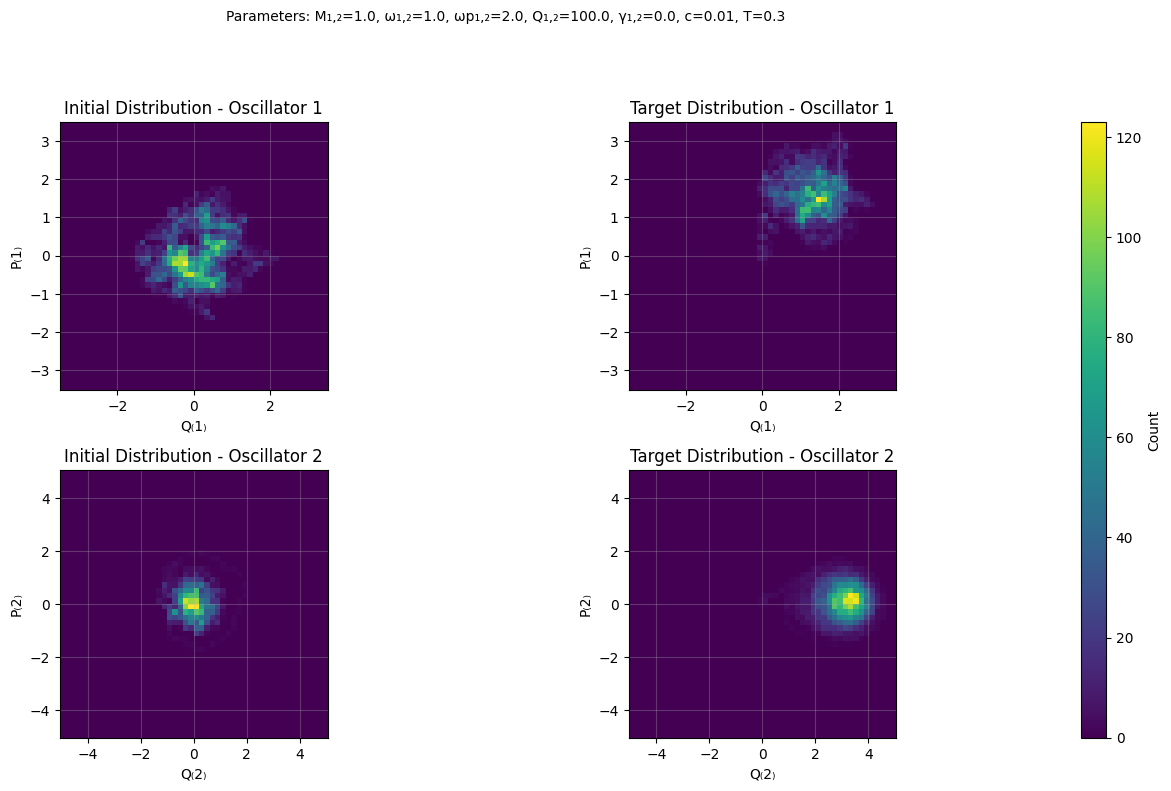

In [6]:
sample_step = 1
# Create figure with proper spacing for all plots and colorbar
fig = plt.figure(figsize=(15, 8))
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.05], wspace=0.2, hspace=0.3)

# Create subplots for both oscillators
ax1_osc1 = fig.add_subplot(gs[0, 0])  # Top left (Osc1 initial)
ax1_osc2 = fig.add_subplot(gs[1, 0])  # Bottom left (Osc2 initial)
ax2_osc1 = fig.add_subplot(gs[0, 1])  # Top right (Osc1 target)
ax2_osc2 = fig.add_subplot(gs[1, 1])  # Bottom right (Osc2 target)
cax = fig.add_subplot(gs[:, 2])        # Colorbar on right

# Get global min/max for consistent axes (for both oscillators)
all_Q1 = jnp.concatenate([sde_samples_QP_target[:, 0], sde_samples_QP_0[:, 0]])
all_P1 = jnp.concatenate([sde_samples_QP_target[:, 1], sde_samples_QP_0[:, 1]])
all_Q2 = jnp.concatenate([sde_samples_QP_target[:, 2], sde_samples_QP_0[:, 2]])
all_P2 = jnp.concatenate([sde_samples_QP_target[:, 3], sde_samples_QP_0[:, 3]])

q1_lim = max(abs(all_Q1.min()), abs(all_Q1.max()))
p1_lim = max(abs(all_P1.min()), abs(all_P1.max()))
q2_lim = max(abs(all_Q2.min()), abs(all_Q2.max()))
p2_lim = max(abs(all_P2.min()), abs(all_P2.max()))

lim1 = max(q1_lim, p1_lim) * 1.1  # Add 10% margin for oscillator 1
lim2 = max(q2_lim, p2_lim) * 1.1  # Add 10% margin for oscillator 2

# Plot distributions
bins = 50
range_lim1 = [[-lim1, lim1], [-lim1, lim1]]
range_lim2 = [[-lim2, lim2], [-lim2, lim2]]

# Initial state plots
hist1_osc1 = ax1_osc1.hist2d(sde_samples_QP_0[::sample_step, 0], 
                            sde_samples_QP_0[::sample_step, 1], 
                            bins=bins, cmap='viridis', range=range_lim1)
hist1_osc2 = ax1_osc2.hist2d(sde_samples_QP_0[::sample_step, 2], 
                            sde_samples_QP_0[::sample_step, 3], 
                            bins=bins, cmap='viridis', range=range_lim2)

# Target state plots
hist2_osc1 = ax2_osc1.hist2d(sde_samples_QP_target[::sample_step, 0], 
                            sde_samples_QP_target[::sample_step, 1], 
                            bins=bins, cmap='viridis', range=range_lim1)
hist2_osc2 = ax2_osc2.hist2d(sde_samples_QP_target[::sample_step, 2], 
                            sde_samples_QP_target[::sample_step, 3], 
                            bins=bins, cmap='viridis', range=range_lim2)

# Set properties for all axes
for ax, lim, osc_num in [(ax1_osc1, lim1, 1), (ax1_osc2, lim2, 2), 
                         (ax2_osc1, lim1, 1), (ax2_osc2, lim2, 2)]:
    ax.set_aspect('equal')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(f'Q₍{osc_num}₎')
    ax.set_ylabel(f'P₍{osc_num}₎')

# Titles
ax1_osc1.set_title('Initial Distribution - Oscillator 1')
ax1_osc2.set_title('Initial Distribution - Oscillator 2')
ax2_osc1.set_title('Target Distribution - Oscillator 1')
ax2_osc2.set_title('Target Distribution - Oscillator 2')

# Add colorbar
plt.colorbar(hist1_osc1[3], cax=cax, label='Count')

# Compact parameter title
title = (f'Parameters: M₁,₂={M1}, ω₁,₂={w1}, ωp₁,₂={wp1}, '
         f'Q₁,₂={Q1}, γ₁,₂={gamma1}, c={c}, T={T}')
plt.suptitle(title, y=1.02, size=10)

plt.show()

#### Compute the analytical marginals of the target distribution; assuming a Boltzmann distribution --> do not agree!!

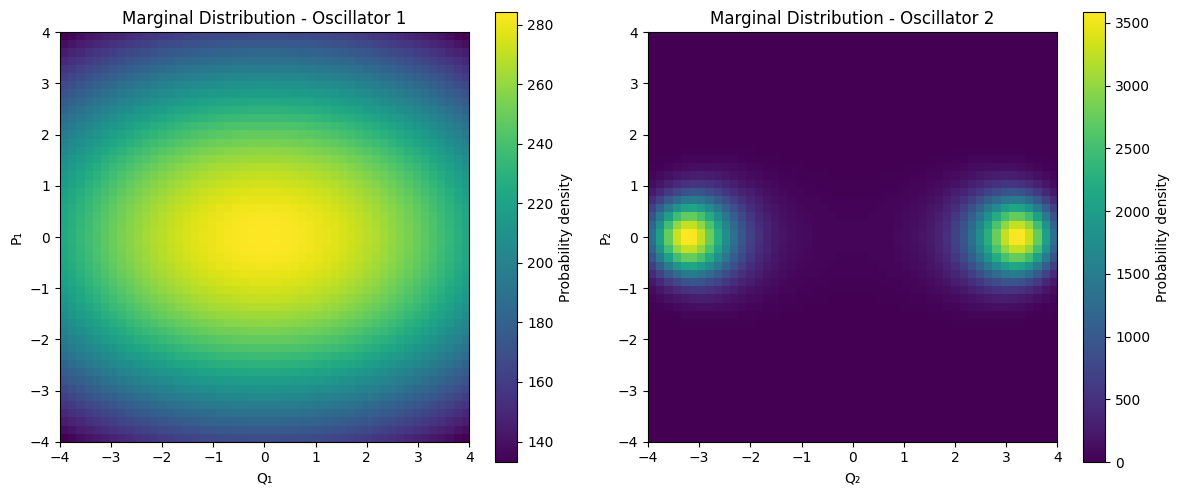

In [7]:
import numpy as np
from scipy import integrate

# Define integration bounds
BOUND = 4  # Set integration bound to 10

# Define the Hamiltonian
def H(Q1, P1, Q2, P2):
    return Hamiltonian(Q1, P1, Q2, P2, args_target)

# Define the Boltzmann distribution
def boltzmann(Q1, P1, Q2, P2, kbT=k_B*T/4):
    return np.exp(-H(Q1, P1, Q2, P2)/kbT)

# Calculate marginal for oscillator 1 (integrating out Q2, P2)
def marginal_osc1(Q1, P1):
    def integrand(x):
        Q2, P2 = x
        return boltzmann(Q1, P1, Q2, P2)
    
    result = integrate.dblquad(lambda P2, Q2: integrand([Q2, P2]), 
                             -BOUND, BOUND,  # Q2 bounds
                             lambda x: -BOUND, lambda x: BOUND)  # P2 bounds
    return result[0]

# Calculate marginal for oscillator 2 (integrating out Q1, P1)
def marginal_osc2(Q2, P2):
    def integrand(x):
        Q1, P1 = x
        return boltzmann(Q1, P1, Q2, P2)
    
    result = integrate.dblquad(lambda P1, Q1: integrand([Q1, P1]), 
                             -BOUND, BOUND,  # Q1 bounds
                             lambda x: -BOUND, lambda x: BOUND)  # P1 bounds
    return result[0]

# Create grid for visualization (using same BOUND for consistency)
q = np.linspace(-BOUND, BOUND, 50)
p = np.linspace(-BOUND, BOUND, 50)
Q, P = np.meshgrid(q, p)

# Calculate marginal distributions
marginal1 = np.zeros_like(Q)
marginal2 = np.zeros_like(Q)

for i in range(len(q)):
    for j in range(len(p)):
        marginal1[i,j] = marginal_osc1(Q[i,j], P[i,j])
        marginal2[i,j] = marginal_osc2(Q[i,j], P[i,j])

# Plot the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

im1 = ax1.imshow(marginal1, extent=[-BOUND, BOUND, -BOUND, BOUND], origin='lower', aspect='equal')
ax1.set_title('Marginal Distribution - Oscillator 1')
ax1.set_xlabel('Q₁')
ax1.set_ylabel('P₁')

im2 = ax2.imshow(marginal2, extent=[-BOUND, BOUND, -BOUND, BOUND], origin='lower', aspect='equal')
ax2.set_title('Marginal Distribution - Oscillator 2')
ax2.set_xlabel('Q₂')
ax2.set_ylabel('P₂')

plt.colorbar(im1, ax=ax1, label='Probability density')
plt.colorbar(im2, ax=ax2, label='Probability density')

plt.tight_layout()
plt.show()